# Car Price Prediction using Machine Learning

## Project Overview

This project develops a machine learning regression model to predict car prices using vehicle-related features such as horsepower, engine size, mileage, and fuel efficiency.

The project demonstrates:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression model training
- Model evaluation
- Prediction analysis

The objective is to understand the factors influencing car prices and build an accurate predictive model.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use('default')
sns.set_theme(style="whitegrid")

# Loading the Dataset

The dataset contains multiple automobile specifications along with car prices.

In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/Auto.csv"

df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


# Dataset Information and Statistical Summary

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(392, 9)

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 27.7+ KB
None

Statistical Summary:


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


# Data Cleaning

The horsepower column contains non-numeric values which are cleaned before model training.

In [4]:
df['horsepower'] = pd.to_numeric(
    df['horsepower'],
    errors='coerce'
)

df = df.dropna()

df.reset_index(drop=True, inplace=True)

# Correlation Heatmap

The heatmap visualizes relationships between numerical variables.

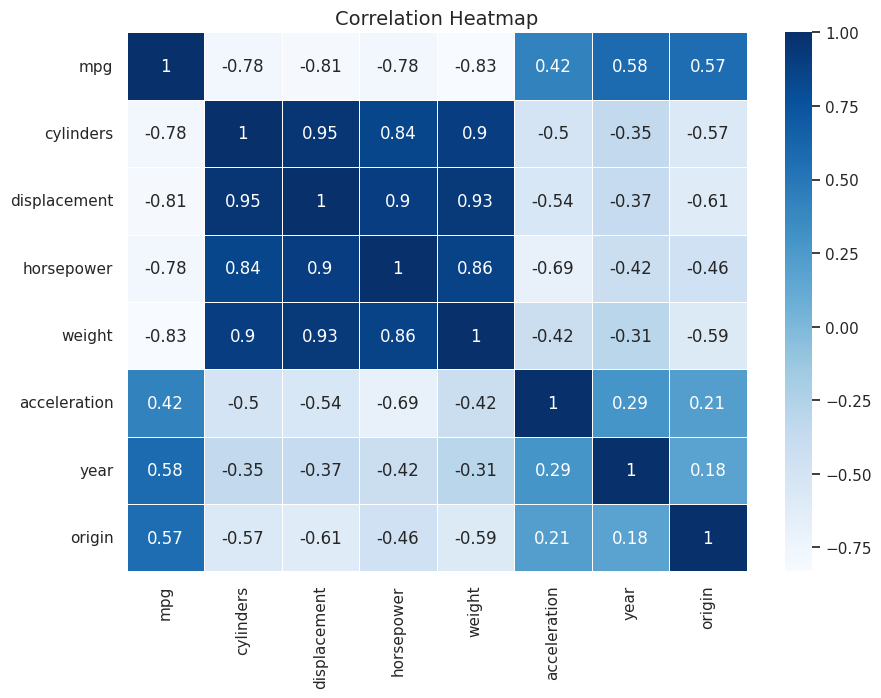

In [5]:
plt.figure(figsize=(10,7))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=14)

plt.show()

# Car Price Distribution

This visualization shows the distribution of car prices in the dataset.

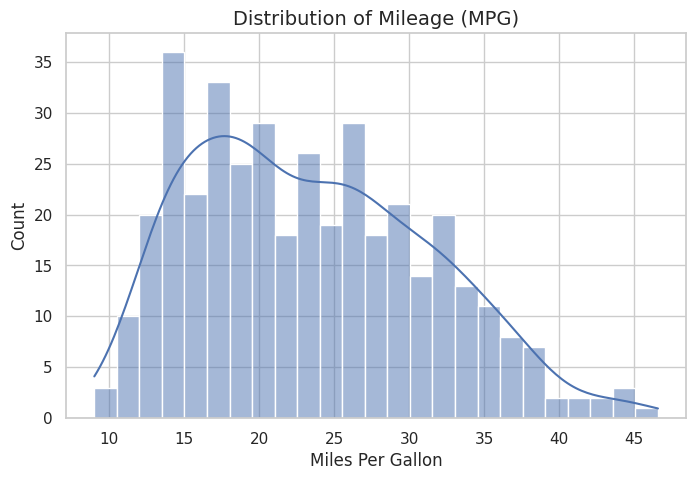

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['mpg'],
    bins=25,
    kde=True
)

plt.title('Distribution of Mileage (MPG)', fontsize=14)
plt.xlabel('Miles Per Gallon')

plt.show()

# Relationship Between Horsepower and Mileage

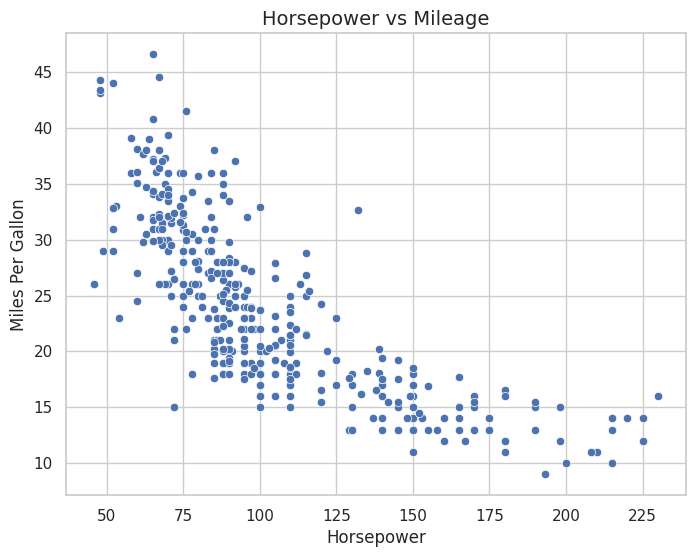

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='horsepower',
    y='mpg'
)

plt.title('Horsepower vs Mileage', fontsize=14)
plt.xlabel('Horsepower')
plt.ylabel('Miles Per Gallon')

plt.show()

# Feature Engineering

Categorical variables are encoded for machine learning processing.

In [8]:
encoder = LabelEncoder()

df['origin'] = encoder.fit_transform(df['origin'])
df['name'] = encoder.fit_transform(df['name'])

# Feature and Target Selection

The model predicts vehicle mileage using automobile characteristics.

In [9]:
X = df.drop('mpg', axis=1)
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

A Random Forest Regressor is used to predict vehicle mileage.

In [11]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

# Model Prediction

In [12]:
y_pred = model.predict(X_test_scaled)

# Model Evaluation

The regression model is evaluated using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:")
print(round(mae, 2))

print("\nMean Squared Error:")
print(round(mse, 2))

print("\nR² Score:")
print(round(r2, 4))

Mean Absolute Error:
1.67

Mean Squared Error:
5.73

R² Score:
0.8877


# Actual vs Predicted Values

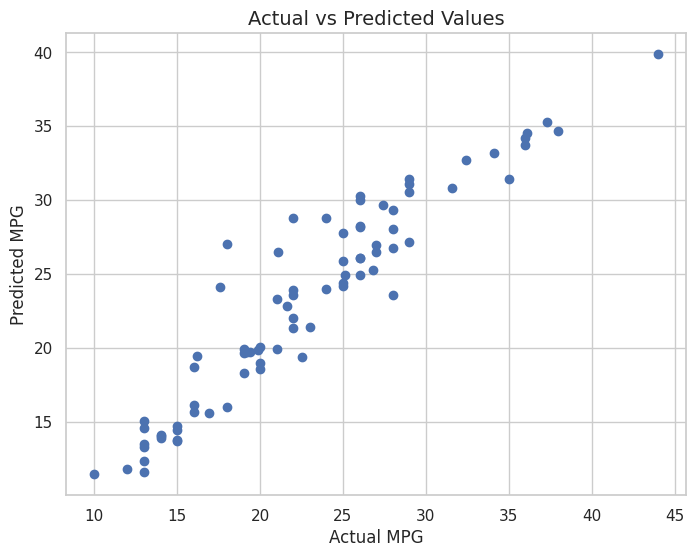

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')

plt.title('Actual vs Predicted Values', fontsize=14)

plt.show()

# Feature Importance Analysis

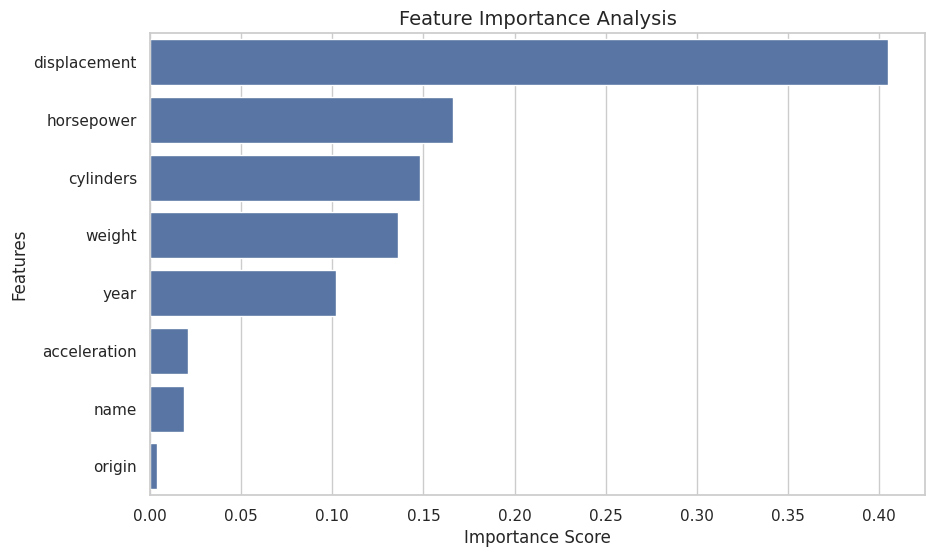

In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance Analysis', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()

# Conclusion

The machine learning model successfully predicted vehicle mileage using automobile characteristics.

Key findings:
- Horsepower and weight strongly influenced mileage prediction.
- The Random Forest model achieved strong predictive performance.
- Feature engineering and preprocessing improved model effectiveness.

This project demonstrates the practical application of regression techniques in automotive data analytics.